## Differntial targeting (DT) of small RNAs in allopolyploids and parental species
======================================================== <br>
Differential targeting (DT) of small RNAs comparing two sibling allopolyploids (_Dactylorhiza majalis_ and _D. traunsteineri_) towards the parental species (_D. fuchsii_ and _D. incarnata_). <br>
The differential targeting of small RNAs were analyzed in three data sets. 
1. Summing the count of all length (20-24nt) of small RNA into one count per sample.
2. Summing the count for the length 20-23nt into one count per sample.
3. Keeping the 24 nt small RNAs separate.

The first set will then be used when focusing on genes in the downstream analysis while the second and third will be used when focusing on transposable elements (TEs). <br>
The datasets has been compiled prior to the edgeR analysis and can be viewed in `notebooks/divide_count_table.ipynb`.

The DT analysis was preformed using edgeR. <br>

To keep this notebook cleaner, any custom function used are kept in the script `scripts/used_functions.R`.

First load the required libraries, set the working directory and load a R script with custom functions used.


In [3]:
library("tidyverse")
library("stringr") 
library("edgeR")
library("ggplot2")

setwd("/home/mier0006/Documents/projects/phd_dact/smRNA_dact/")
source("dact-sRNAs/scripts/used_functions.R")

### Finding genome wide DT peaks analysing 20-24nt small RNAs to later use in gene analysis
Load the raw table of counts

The rows in the table represent small RNA peaks across the reference genome used (_D. incarnata_ v.1.0). 



In [4]:
spCOL <- c("#e786e6", "#FFD154", "#B2182B", "#009ACD")

# load raw count data
df <- read.table("01_counts/dactylorhiza_sRNA-read-counts_MM-fraction_per-sample-summed-20-24nt.txt", sep="\t", header=T)

head(df)

,peakID,fB1_1804,fB5_1855,fP1_1001,fPx_1707n,iA11_1586,iB5_1870,iS3_1904,iS4_1908,mA10_1573c,⋯,tA9_1641,tB2_1798,tB2_1805,tB3_1812,tB5_1826,tB5_1830,tB5_1833,tS3_1901n,tS3_1902,tS5_1918
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,scaffold1_42451085:10002001-10002100,0.50,0.00,0.10,0.84,0.00,0.12,1.00,0.00,0.00,⋯,0.00,0.00,2.00,0.00,0.00,0.00,0.00,0.50,1.75,0.30
2,scaffold1_42451085:10003301-10003400,0.14,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,⋯,0.40,0.07,0.35,0.00,0.07,0.22,0.50,0.40,0.07,0.57
3,scaffold1_42451085:10003501-10003600,0.00,0.14,0.00,0.00,0.00,0.39,0.46,0.08,0.78,⋯,0.07,0.37,0.00,0.77,0.56,0.59,1.20,0.50,0.07,0.05
4,scaffold1_42451085:1000401-1000500,1.00,0.00,0.58,0.00,0.00,0.00,0.04,1.00,0.00,⋯,0.00,0.33,0.37,0.66,0.00,1.00,0.33,0.00,0.67,0.37
5,scaffold1_42451085:10004401-10004600,0.11,0.12,0.27,0.00,0.15,0.23,0.68,0.00,0.07,⋯,0.00,0.11,0.02,0.61,0.36,0.69,0.22,0.12,0.12,0.14
6,scaffold1_42451085:10005201-10005300,0.00,0.00,0.12,0.00,0.00,0.25,0.13,0.07,0.00,⋯,0.04,0.10,0.13,0.34,0.26,0.38,0.17,0.34,0.14,0.34


Filter the data on expression and samples with data. <br>
We want there to be a minimumn of one count per million (cpm) for at least 25% of the number of samples in a group and a minimum of two samples. <br>
Save the filtered data to a file

In [5]:
df_filtered <- filter_smRNA_by_exp(D=df, min_samples=2, cpm_level=1, sample_prop=0.25)
write.table(df_filtered, "01_counts/dactylorhiza_sRNA-read-counts_MM-fraction_per-sample-summed-20-24nt_filtered.txt",
            sep="\t", col.names=T, row.names=F, quote=F)
print(paste("Number of rows before filtering:", nrow(df), sep=" "))
print(paste("Number of rows after filtering:", nrow(df_filtered), sep=" "))

[1] "Number of rows before filtering: 2430006"
[1] "Number of rows after filtering: 84367"


For analysis purposes make the data into a matrix instead of a data frame <br>
name the rows by the peak id

In [6]:
M <- as.matrix(df_filtered[,c(2:ncol(df_filtered))])
row.names(M) <- df_filtered$peakID
head(M)

,fB1_1804,fB5_1855,fP1_1001,fPx_1707n,iA11_1586,iB5_1870,iS3_1904,iS4_1908,mA10_1573c,mA13_1661,⋯,tA9_1641,tB2_1798,tB2_1805,tB3_1812,tB5_1826,tB5_1830,tB5_1833,tS3_1901n,tS3_1902,tS5_1918
scaffold1_42451085:10007201-10007600,0.15,2.15,0.83,0.05,4.56,10.76,0.38,0.06,4.72,1.00,⋯,0.15,7.23,2.05,11.14,4.73,8.85,17.65,1.00,1.28,1.29
scaffold1_42451085:10011901-10012500,18.27,7.27,30.26,1.12,6.54,9.13,21.56,4.59,11.27,7.91,⋯,6.92,22.24,6.61,18.07,19.56,22.22,25.43,4.17,12.47,17.80
scaffold1_42451085:10096601-10096800,1.61,3.21,3.93,0.42,1.86,3.86,16.10,1.19,3.71,6.08,⋯,3.48,8.32,1.06,10.97,9.62,12.83,16.91,2.93,4.97,7.76
scaffold1_42451085:10118801-10119100,2.97,8.91,8.94,1.02,3.55,13.75,15.83,2.50,1.75,3.66,⋯,1.88,5.12,1.50,14.54,15.02,7.55,15.88,1.78,5.36,6.55
scaffold1_42451085:10121101-10121400,0.57,2.05,1.25,0.50,2.33,2.53,13.00,1.51,1.06,1.33,⋯,1.50,6.50,2.00,7.75,7.86,10.33,8.80,2.00,2.12,0.58
scaffold1_42451085:10123501-10123900,11.80,7.36,19.75,1.25,2.19,6.43,5.98,0.00,3.86,5.61,⋯,1.58,13.91,2.43,19.07,6.01,17.96,17.44,3.51,2.53,11.72


Make a DGE object with the data

In [7]:
species_groups = substr(colnames(M),1,1)

dge <- DGEList(M, group=species_groups)

dge$samples

,group,lib.size,norm.factors
,<fct>,<dbl>,<dbl>
fB1_1804,f,4216912.2,1
fB5_1855,f,3314718.7,1
fP1_1001,f,6075961.9,1
fPx_1707n,f,2263280.5,1
iA11_1586,i,560989.8,1
iB5_1870,i,1307717.5,1
iS3_1904,i,3300928.0,1
iS4_1908,i,1034398.1,1
mA10_1573c,m,1825546.7,1


Calculate norm factors using the TMM method (trimmed mean of medians)

In [8]:
dge <- calcNormFactors(dge, method = "TMM")
dge$samples

,group,lib.size,norm.factors
,<fct>,<dbl>,<dbl>
fB1_1804,f,4216912.2,0.8635323
fB5_1855,f,3314718.7,1.0654735
fP1_1001,f,6075961.9,0.9264027
fPx_1707n,f,2263280.5,0.2581929
iA11_1586,i,560989.8,1.4245711
iB5_1870,i,1307717.5,1.6007088
iS3_1904,i,3300928.0,1.5559197
iS4_1908,i,1034398.1,0.8524856
mA10_1573c,m,1825546.7,0.8581508


Plot a PCA and MDS of the data to look at dispersion

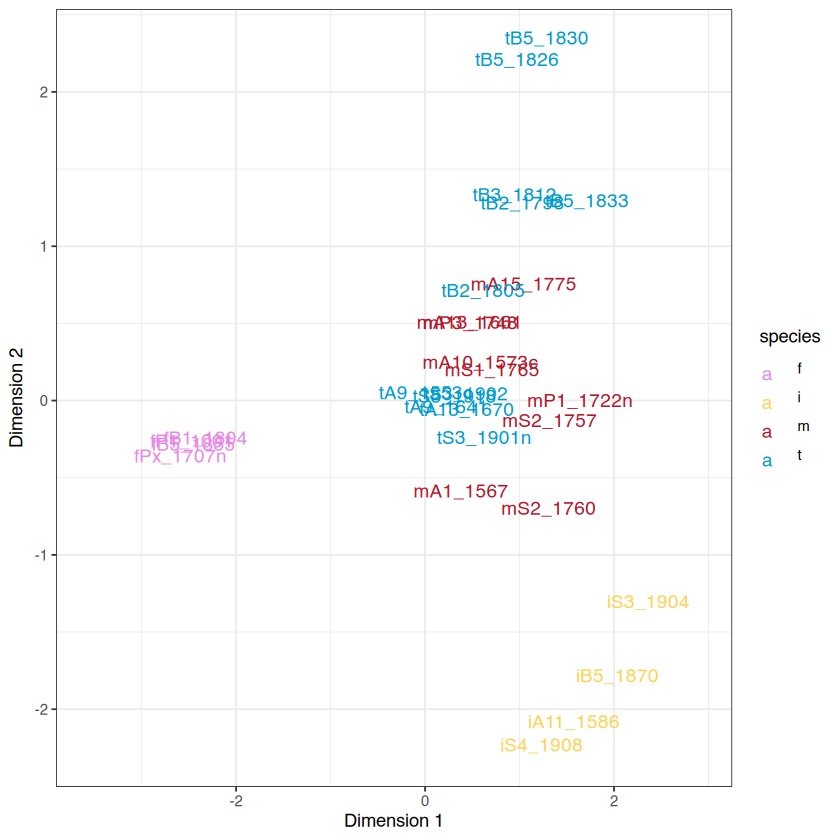

In [9]:
normCounts <- log2(cpm(dge$counts)+1)
mds <- plotMDS(normCounts, plot=FALSE)
forGG <- data.frame(Dim1=mds$x, Dim2=mds$y) %>%
    add_column(sample=rownames(mds$distance.matrix.squared))%>%
    mutate(species=substr(sample,1,1))
rownames(forGG) <- seq(1,nrow(forGG))
mds_plot <- ggplot(forGG) + 
geom_text(aes(x=Dim1, y=Dim2, label=sample, colour=species) ,hjust=0, vjust=0, size=4) +
scale_colour_manual(values=spCOL) +
xlab("Dimension 1") + 
ylab("Dimension 2") + 
xlim(min(forGG$Dim1)-0.5, max(forGG$Dim1)+1) +
theme_bw()

mds_plot

Make a matrix for the underlying model to use

In [10]:
design <- model.matrix(~ 0 + dge$samples$group)
colnames(design) <- levels(dge$samples$group)
print(design)

   f i m t
1  1 0 0 0
2  1 0 0 0
3  1 0 0 0
4  1 0 0 0
5  0 1 0 0
6  0 1 0 0
7  0 1 0 0
8  0 1 0 0
9  0 0 1 0
10 0 0 1 0
11 0 0 1 0
12 0 0 1 0
13 0 0 1 0
14 0 0 1 0
15 0 0 1 0
16 0 0 1 0
17 0 0 1 0
18 0 0 0 1
19 0 0 0 1
20 0 0 0 1
21 0 0 0 1
22 0 0 0 1
23 0 0 0 1
24 0 0 0 1
25 0 0 0 1
26 0 0 0 1
27 0 0 0 1
28 0 0 0 1
29 0 0 0 1
attr(,"assign")
[1] 1 1 1 1
attr(,"contrasts")
attr(,"contrasts")$`dge$samples$group`
[1] "contr.treatment"



Estimating dispersion and fit the data to the model

In [11]:
dge <- estimateDisp(dge, design, robust=T)
dge_fit <- glmQLFit(dge, design, robust=T)

Find DT peaks between each polyploid and each parental diploid then adjust p-values for multiple testing

In [12]:
# DT peaks between polyploid m and diploid f
dge_ql_mf  <- glmQLFTest(dge_fit, contrast=makeContrasts(m-f, levels=design))
dge_res_mf <- topTags(dge_ql_mf, n=Inf, adjust.method="BH")
names(dge_res_mf$table) <- paste("MF", names(dge_res_mf$table), sep="_")
# DT peaks between polyploid m and diploid i
dge_ql_mi  <- glmQLFTest(dge_fit, contrast=makeContrasts(m-i, levels=design))
dge_res_mi <- topTags(dge_ql_mi, n=Inf, adjust.method="BH")
names(dge_res_mi$table) <- paste("MI", names(dge_res_mi$table), sep="_")

# DT peaks between polyploid t and diploid f
dge_ql_tf  <- glmQLFTest(dge_fit, contrast=makeContrasts(t-f, levels=design))
dge_res_tf <- topTags(dge_ql_tf, n=Inf, adjust.method="BH")
names(dge_res_tf$table) <- paste("TF", names(dge_res_tf$table), sep="_")
# DT peaks between polyploid t and diploid i
dge_ql_ti  <- glmQLFTest(dge_fit, contrast=makeContrasts(t-i, levels=design))
dge_res_ti <- topTags(dge_ql_ti, n=Inf, adjust.method="BH")
names(dge_res_ti$table) <- paste("TI", names(dge_res_ti$table), sep="_")

Find DT peaks between the two polyploids then adjust p-values for multiple testing

In [13]:
dge_ql_mt  <- glmQLFTest(dge_fit, contrast=makeContrasts(m-t, levels=design))
dge_res_mt <- topTags(dge_ql_mt, n=Inf, adjust.method="BH")
names(dge_res_mt$table) <- paste("MT", names(dge_res_mt$table), sep="_")

Save the output to files
1. combining all polyploid vs diploid outputs
2. the polyploid comparison

In [18]:
# merge all polyploid vs diploid comparisons
m_comp <- cbind(dge_res_mf$table, dge_res_mi$table)
t_comp <- cbind(dge_res_tf$table, dge_res_ti$table)
pd_comp <- cbind(m_comp, t_comp)
pd_comp <- rownames_to_column(pd_comp) 
colnames(pd_comp)[1] <- "peakID"
write.table(pd_comp, "02_DT-analysis/4x-vs-2x_20to24nt.txt",
            sep="\t", col.names=T, row.names=F, quote=F)

# write polyploid comparison
pp_comp <- dge_res_mt$table
pp_comp <- rownames_to_column(pp_comp)
colnames(pp_comp)[1] <- "peakID"
write.table(pp_comp, "02_DT-analysis/tm_20to24nt.txt",
            sep="\t", col.names=T, row.names=F, quote=F)

### Finding genome wide DT peaks analysing 20-23nt small RNAs to later use in TE analysis
repeat all the steps from the previous section

In [19]:
# load raw count data
df <- read.table("01_counts/dactylorhiza_sRNA-read-counts_MM-fraction_per-sample-summed-20-23nt.txt", sep="\t", header=T)
# filter the data
df_filtered <- filter_smRNA_by_exp(D=df, min_samples=2, cpm_level=1, sample_prop=0.25)
write.table(df_filtered, "01_counts/dactylorhiza_sRNA-read-counts_MM-fraction_per-sample-summed-20-23nt_filtered.txt",
            sep="\t", col.names=T, row.names=F, quote=F)
print(paste("Number of rows before filtering:", nrow(df), sep=" "))
print(paste("Number of rows after filtering:", nrow(df_filtered), sep=" "))

[1] "Number of rows before filtering: 2430006"
[1] "Number of rows after filtering: 47614"


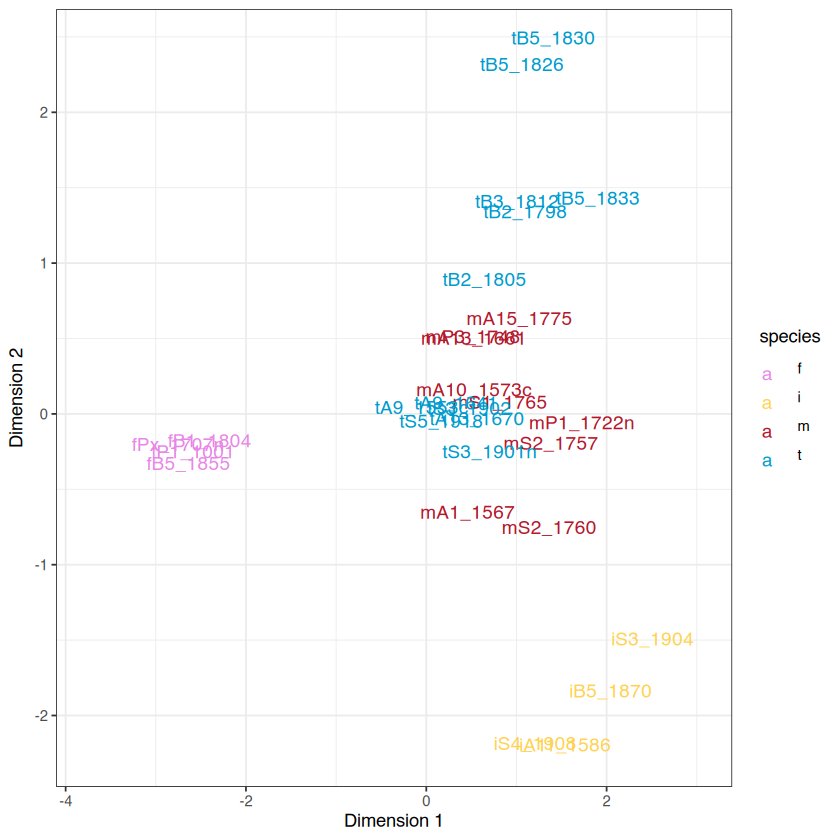

In [20]:
# put the data in a matrix format
M <- as.matrix(df_filtered[,c(2:ncol(df_filtered))])
row.names(M) <- df_filtered$peakID
# make the dge object
species_groups = substr(colnames(M),1,1)
dge <- DGEList(M, group=species_groups)
# calculate normalization factors
dge <- calcNormFactors(dge, method = "TMM")
# make the MDS plot
normCounts <- log2(cpm(dge$counts)+1)
mds <- plotMDS(normCounts, plot=FALSE)
forGG <- data.frame(Dim1=mds$x, Dim2=mds$y) %>%
    add_column(sample=rownames(mds$distance.matrix.squared))%>%
    mutate(species=substr(sample,1,1))
rownames(forGG) <- seq(1,nrow(forGG))
mds_plot <- ggplot(forGG) + 
geom_text(aes(x=Dim1, y=Dim2, label=sample, colour=species) ,hjust=0, vjust=0, size=4) +
scale_colour_manual(values=spCOL) +
xlab("Dimension 1") + 
ylab("Dimension 2") + 
xlim(min(forGG$Dim1)-0.5, max(forGG$Dim1)+1) +
theme_bw()

mds_plot

In [21]:
# make the model
design <- model.matrix(~ 0 + dge$samples$group)
colnames(design) <- levels(dge$samples$group)
# estimate dispertion
dge <- estimateDisp(dge, design, robust=T)
# fit the data to the model
dge_fit <- glmQLFit(dge, design, robust=T)
# find DT peaks
# DT peaks between polyploid m and diploid f
dge_ql_mf  <- glmQLFTest(dge_fit, contrast=makeContrasts(m-f, levels=design))
dge_res_mf <- topTags(dge_ql_mf, n=Inf, adjust.method="BH")
names(dge_res_mf$table) <- paste("MF", names(dge_res_mf$table), sep="_")
# DT peaks between polyploid m and diploid i
dge_ql_mi  <- glmQLFTest(dge_fit, contrast=makeContrasts(m-i, levels=design))
dge_res_mi <- topTags(dge_ql_mi, n=Inf, adjust.method="BH")
names(dge_res_mi$table) <- paste("MI", names(dge_res_mi$table), sep="_")

# DT peaks between polyploid t and diploid f
dge_ql_tf  <- glmQLFTest(dge_fit, contrast=makeContrasts(t-f, levels=design))
dge_res_tf <- topTags(dge_ql_tf, n=Inf, adjust.method="BH")
names(dge_res_tf$table) <- paste("TF", names(dge_res_tf$table), sep="_")
# DT peaks between polyploid t and diploid i
dge_ql_ti  <- glmQLFTest(dge_fit, contrast=makeContrasts(t-i, levels=design))
dge_res_ti <- topTags(dge_ql_ti, n=Inf, adjust.method="BH")
names(dge_res_ti$table) <- paste("TI", names(dge_res_ti$table), sep="_")

# DT peaks between polyploids m and t
dge_ql_mt  <- glmQLFTest(dge_fit, contrast=makeContrasts(m-t, levels=design))
dge_res_mt <- topTags(dge_ql_mt, n=Inf, adjust.method="BH")
names(dge_res_mt$table) <- paste("MT", names(dge_res_mt$table), sep="_")

# merge all polyploid vs diploid comparisons
m_comp <- cbind(dge_res_mf$table, dge_res_mi$table)
t_comp <- cbind(dge_res_tf$table, dge_res_ti$table)
pd_comp <- cbind(m_comp, t_comp)
pd_comp <- rownames_to_column(pd_comp) 
colnames(pd_comp)[1] <- "peakID"
write.table(pd_comp, "02_DT-analysis/4x-vs-2x_20to23nt.txt",
            sep="\t", col.names=T, row.names=F, quote=F)

# write polyploid comparison
pp_comp <- dge_res_mt$table
pp_comp <- rownames_to_column(pp_comp)
colnames(pp_comp)[1] <- "peakID"
write.table(pp_comp, "02_DT-analysis/tm_20to23nt.txt",
            sep="\t", col.names=T, row.names=F, quote=F)

### Finding genome wide DT peaks analysing 24nt small RNAs to later use in TE analysis
repeat all the steps from the previous section

In [22]:
# load raw count data
df <- read.table("01_counts/dactylorhiza_sRNA-read-counts_MM-fraction_per-sample-24nt.txt", sep="\t", header=T)

# filter the data
df_filtered <- filter_smRNA_by_exp(D=df, min_samples=2, cpm_level=1, sample_prop=0.25)
write.table(df_filtered, "01_counts/dactylorhiza_sRNA-read-counts_MM-fraction_per-sample-24nt_filtered.txt",
            sep="\t", col.names=T, row.names=F, quote=F)
print(paste("Number of rows before filtering:", nrow(df), sep=" "))
print(paste("Number of rows after filtering:", nrow(df_filtered), sep=" "))

[1] "Number of rows before filtering: 2430006"
[1] "Number of rows after filtering: 182853"


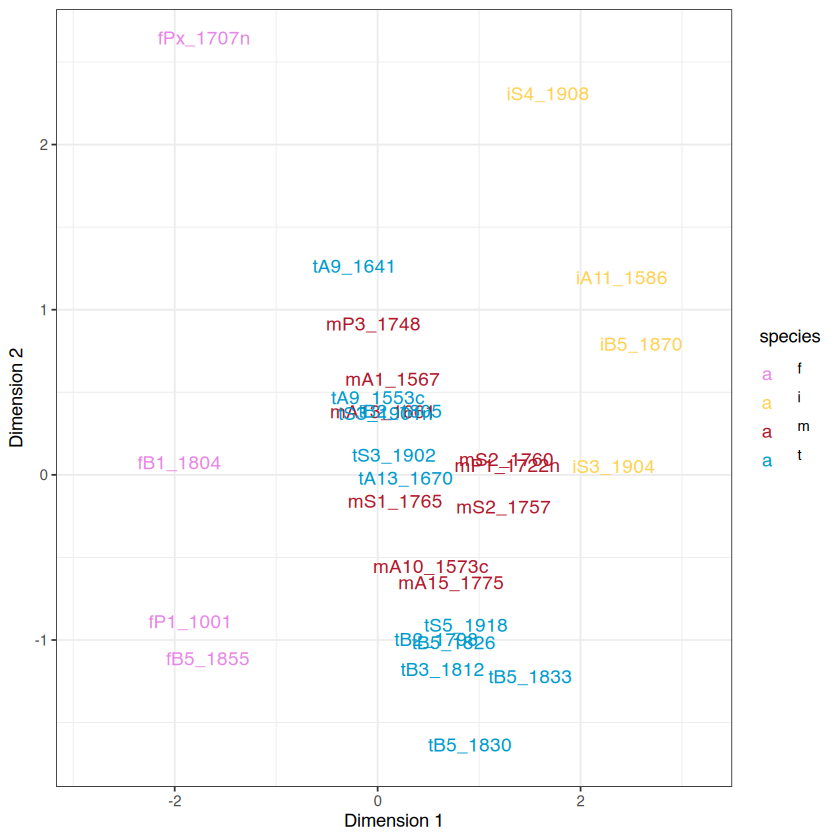

In [21]:
# put the data in a matrix format
M <- as.matrix(df_filtered[,c(2:ncol(df_filtered))])
row.names(M) <- df_filtered$peakID
# make the dge object
species_groups = substr(colnames(M),1,1)
dge <- DGEList(M, group=species_groups)
# calculate normalization factors
dge <- calcNormFactors(dge, method = "TMM")

# make the MDS plot
normCounts <- log2(cpm(dge$counts)+1)
mds <- plotMDS(normCounts, plot=FALSE)
forGG <- data.frame(Dim1=mds$x, Dim2=mds$y) %>%
    add_column(sample=rownames(mds$distance.matrix.squared))%>%
    mutate(species=substr(sample,1,1))
rownames(forGG) <- seq(1,nrow(forGG))
mds_plot <- ggplot(forGG) + 
geom_text(aes(x=Dim1, y=Dim2, label=sample, colour=species) ,hjust=0, vjust=0, size=4) +
scale_colour_manual(values=spCOL) +
xlab("Dimension 1") + 
ylab("Dimension 2") + 
xlim(min(forGG$Dim1)-0.5, max(forGG$Dim1)+1) +
theme_bw()

mds_plot

In [ ]:
# make the model
design <- model.matrix(~ 0 + dge$samples$group)
colnames(design) <- levels(dge$samples$group)
# estimate dispertion
dge <- estimateDisp(dge, design, robust=T)
# fit the data to the model
dge_fit <- glmQLFit(dge, design, robust=T)
# find DT peaks
# DT peaks between polyploid m and diploid f
dge_ql_mf  <- glmQLFTest(dge_fit, contrast=makeContrasts(m-f, levels=design))
dge_res_mf <- topTags(dge_ql_mf, n=Inf, adjust.method="BH")
names(dge_res_mf$table) <- paste("MF", names(dge_res_mf$table), sep="_")
# DT peaks between polyploid m and diploid i
dge_ql_mi  <- glmQLFTest(dge_fit, contrast=makeContrasts(m-i, levels=design))
dge_res_mi <- topTags(dge_ql_mi, n=Inf, adjust.method="BH")
names(dge_res_mi$table) <- paste("MI", names(dge_res_mi$table), sep="_")

# DT peaks between polyploid t and diploid f
dge_ql_tf  <- glmQLFTest(dge_fit, contrast=makeContrasts(t-f, levels=design))
dge_res_tf <- topTags(dge_ql_tf, n=Inf, adjust.method="BH")
names(dge_res_tf$table) <- paste("TF", names(dge_res_tf$table), sep="_")
# DT peaks between polyploid t and diploid i
dge_ql_ti  <- glmQLFTest(dge_fit, contrast=makeContrasts(t-i, levels=design))
dge_res_ti <- topTags(dge_ql_ti, n=Inf, adjust.method="BH")
names(dge_res_ti$table) <- paste("TI", names(dge_res_ti$table), sep="_")

# DT peaks between polyploids m and t
dge_ql_mt  <- glmQLFTest(dge_fit, contrast=makeContrasts(m-t, levels=design))
dge_res_mt <- topTags(dge_ql_mt, n=Inf, adjust.method="BH")
names(dge_res_mt$table) <- paste("MT", names(dge_res_mt$table), sep="_")

# merge all polyploid vs diploid comparisons
m_comp <- cbind(dge_res_mf$table, dge_res_mi$table)
t_comp <- cbind(dge_res_tf$table, dge_res_ti$table)
pd_comp <- cbind(m_comp, t_comp)
pd_comp <- rownames_to_column(pd_comp) 
colnames(pd_comp)[1] <- "peakID"
write.table(pd_comp, "02_DT-analysis/4x-vs-2x_24nt.txt",
            sep="\t", col.names=T, row.names=F, quote=F)

# write polyploid comparison
pp_comp <- dge_res_mt$table
pp_comp <- rownames_to_column(pp_comp)
colnames(pp_comp)[1] <- "peakID"
write.table(pp_comp, "02_DT-analysis/tm_24nt.txt",
            sep="\t", col.names=T, row.names=F, quote=F)